C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

Loaded Training Data: (3461, 60, 1)


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


--- Starting Training for 2000 Epochs ---


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0/2000 [D loss: 0.6902, acc.: 99.22%] [G loss: 0.6941]
Epoch 100/2000 [D loss: 0.7008, acc.: 50.76%] [G loss: 0.6748]
Epoch 200/2000 [D loss: 0.7027, acc.: 50.37%] [G loss: 0.6711]
Epoch 300/2000 [D loss: 0.7044, acc.: 50.24%] [G loss: 0.6680]
Epoch 400/2000 [D loss: 0.7052, acc.: 50.17%] [G loss: 0.6664]
Epoch 500/2000 [D loss: 0.7057, acc.: 50.13%] [G loss: 0.6655]
Epoch 600/2000 [D loss: 0.7061, acc.: 50.10%] [G loss: 0.6648]
Epoch 700/2000 [D loss: 0.7063, acc.: 50.08%] [G loss: 0.6643]
Epoch 800/2000 [D loss: 0.7065, acc.: 50.06%] [G loss: 0.6640]
Epoch 900/2000 [D loss: 0.7066, acc.: 50.05%] [G loss: 0.6637]
Epoch 1000/2000 [D loss: 0.7067, acc.: 50.05%] [G loss: 0.6635]
Epoch 1100/2000 [D loss: 0.7068, acc.: 50.04%] [G loss: 0.6633]
Epoch 1200/2000 [D loss: 0.7069, acc.: 50.03%] [G loss: 0.6632]
Epoch 1300/2000 [D loss: 0.7070, acc.: 50.03%] [G loss: 0.6630]
Epoch 1400/2000 [D loss: 0.7070, acc.: 50.02%] [G loss: 0.6629]
Epoch 1500/2000 [D loss: 0.7071, acc.: 50.01%] [G lo

--- Training Complete in 5.84 minutes ---
Generator Saved to c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\Generative Adversarial Networks (GANs) for Market Simulation\models


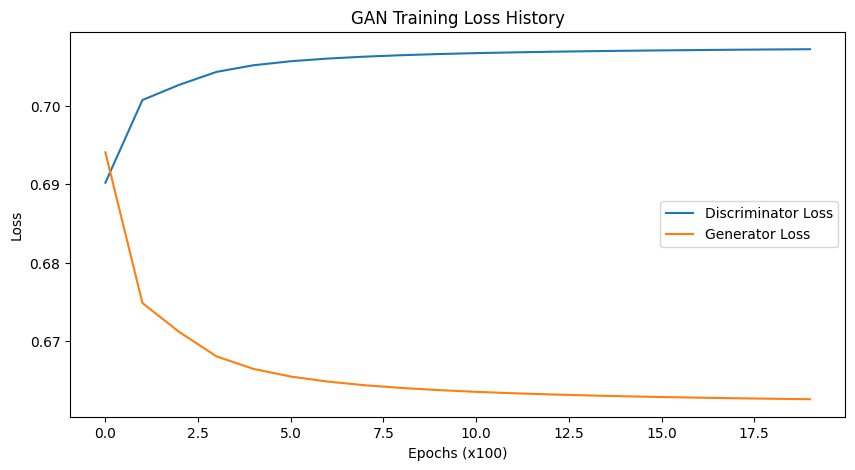

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time

# --- Configuration ---
# Hyperparameters
EPOCHS = 2000        # Total training rounds
BATCH_SIZE = 32      # How many samples per gradient update
SAMPLE_INTERVAL = 200 # How often to save a check-up graph

# Load Data 
BASE_PATH = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_PATH, 'data')
MODEL_PATH = os.path.join(BASE_PATH, 'models')
IMAGE_PATH = os.path.join(BASE_PATH, 'images')

# Load the prepared training data
X_train = np.load(os.path.join(DATA_PATH, 'training_data.npy'))
print(f"Loaded Training Data: {X_train.shape}")

# Re-Initialize Models (Copying architecture from Step 2 to ensure clean state)
# Ideally, we would import these, but for a clean notebook run, we redefine quickly:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, LeakyReLU, Input, Reshape
from tensorflow.keras.optimizers import Adam

SEQ_LEN = 60
LATENT_DIM = 100

def build_generator():
    model = Sequential([
        Input(shape=(LATENT_DIM,)),
        Dense(SEQ_LEN * 128),
        LeakyReLU(alpha=0.2),
        Reshape((SEQ_LEN, 128)),
        LSTM(128, return_sequences=True),
        LSTM(64, return_sequences=True),
        Dense(1, activation='tanh')
    ])
    return model

def build_discriminator():
    model = Sequential([
        Input(shape=(SEQ_LEN, 1)),
        LSTM(64, return_sequences=True),
        LeakyReLU(alpha=0.2),
        LSTM(32),
        LeakyReLU(alpha=0.2),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(0.0002, 0.5)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Initialize
generator = build_generator()
discriminator = build_discriminator()

# Build Combined GAN
discriminator.trainable = False
gan_input = Input(shape=(LATENT_DIM,))
gan_output = discriminator(generator(gan_input))
gan = Model(gan_input, gan_output)
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))

# --- TRAINING LOOP ---

# Labels for real and fake data
real = np.ones((BATCH_SIZE, 1))
fake = np.zeros((BATCH_SIZE, 1))

d_losses = []
g_losses = []

print(f"--- Starting Training for {EPOCHS} Epochs ---")
start_time = time.time()

for epoch in range(EPOCHS):
    
    # ---------------------
    #  1. Train Discriminator
    # ---------------------
    
    # Select a random batch of real stock sequences
    idx = np.random.randint(0, X_train.shape[0], BATCH_SIZE)
    real_seqs = X_train[idx]
    
    # Generate a batch of fake sequences
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    gen_seqs = generator.predict(noise, verbose=0)
    
    # Train the Discriminator (Real classified as 1, Fake classified as 0)
    d_loss_real = discriminator.train_on_batch(real_seqs, real)
    d_loss_fake = discriminator.train_on_batch(gen_seqs, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # ---------------------
    #  2. Train Generator
    # ---------------------
    
    # Train the Generator (We want the Discriminator to mistake these as Real=1)
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    g_loss = gan.train_on_batch(noise, real) # Note: we pass 'real' labels here to trick D

    # ---------------------
    #  3. Logging
    # ---------------------
    if epoch % 100 == 0:
        print(f"Epoch {epoch}/{EPOCHS} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")
        d_losses.append(d_loss[0])
        g_losses.append(g_loss)

    # ---------------------
    #  4. Save Sample Images
    # ---------------------
    if epoch % SAMPLE_INTERVAL == 0:
        plt.figure(figsize=(10, 4))
        plt.plot(gen_seqs[0], label="Generated (Fake)")
        plt.plot(real_seqs[0], label="Real Market Data", alpha=0.6)
        plt.title(f"Generator Output at Epoch {epoch}")
        plt.legend()
        plt.savefig(os.path.join(IMAGE_PATH, f"gan_training_epoch_{epoch}.png"))
        plt.close()

end_time = time.time()
print(f"--- Training Complete in {(end_time - start_time)/60:.2f} minutes ---")

# Save the Final Models
generator.save(os.path.join(MODEL_PATH, 'generator_final.h5'))
print(f"Generator Saved to {MODEL_PATH}")

# Plot Loss History
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.title("GAN Training Loss History")
plt.xlabel("Epochs (x100)")
plt.ylabel("Loss")
plt.legend()
plt.savefig(os.path.join(IMAGE_PATH, "gan_loss_history.png"))
plt.show()